In [2]:
import pandas as pd

data = {
    "sleep_hours":[8, 7, 6, 5, 8],
    "screen_time":[3, 4, 6, 7, 2],
    "work_hours":[6, 7, 8, 9, 5],
    "mood":[4, 3, 2, 1, 5],
    "execrise_minutes":[40, 30, 20, 10, 50],
    "stress":["Low", "Moderate", "high", "High", "Low"]
}

df = pd.DataFrame(data)

df



,sleep_hours,screen_time,work_hours,mood,execrise_minutes,stress
0,8,3,6,4,40,Low
1,7,4,7,3,30,Moderate
2,6,6,8,2,20,high
3,5,7,9,1,10,High
4,8,2,5,5,50,Low


In [3]:
df.to_csv("stress_data.csv", index=False)

In [4]:
pd.read_csv("stress_data.csv").head()

,sleep_hours,screen_time,work_hours,mood,execrise_minutes,stress
0,8,3,6,4,40,Low
1,7,4,7,3,30,Moderate
2,6,6,8,2,20,high
3,5,7,9,1,10,High
4,8,2,5,5,50,Low


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["stress_encoded"] = le.fit_transform(df["stress"])

df

,sleep_hours,screen_time,work_hours,mood,execrise_minutes,stress,stress_encoded
0,8,3,6,4,40,Low,1
1,7,4,7,3,30,Moderate,2
2,6,6,8,2,20,high,3
3,5,7,9,1,10,High,0
4,8,2,5,5,50,Low,1


In [6]:
x = df.drop(["stress", "stress_encoded"],axis=1)
y = df["stress_encoded"]

x,y

(   sleep_hours  screen_time  work_hours  mood  execrise_minutes
 0            8            3           6     4                40
 1            7            4           7     3                30
 2            6            6           8     2                20
 3            5            7           9     1                10
 4            8            2           5     5                50,
 0    1
 1    2
 2    3
 3    0
 4    1
 Name: stress_encoded, dtype: int64)

In [7]:
#Train-Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

x_train.shape, x_test.shape


((4, 5), (1, 5))

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy =", accuracy)

Model Accuracy = 0.0


In [27]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[0 0]
 [1 0]]
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\anaconda3\Lib\sit

In [28]:
# example input
# sleep_hours, screen_time, work_hours, mood, exercise_minutes

new_data = [[6, 5, 8, 3, 20]]

prediction = model.predict(new_data)

print("Predicted Stress Level =", prediction)

Predicted Stress Level = [3]


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [29]:
le.classes_

array(['High', 'Low', 'Moderate', 'high'], dtype=object)

In [30]:
import joblib

joblib.dump(model, "mental_stress_model.pkl")

['mental_stress_model.pkl']

In [32]:
import joblib

loaded_model = joblib.load("mental_stress_model.pkl")

In [36]:
import numpy as np

# create input as numpy array (same order as training)
new_input = np.array([[6, 5, 8, 2, 20]])

predicted_stress = loaded_model.predict(new_input)
predicted_stress

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([3])

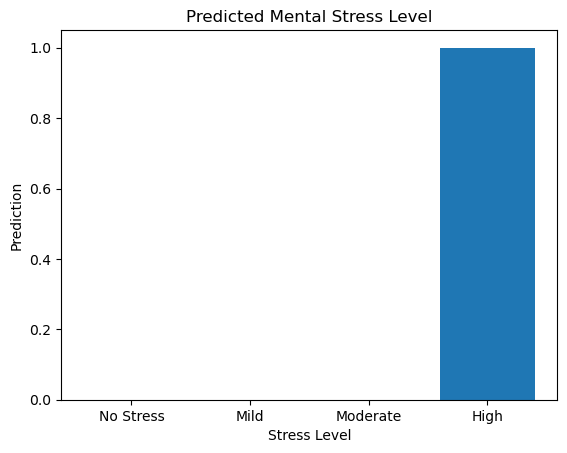

In [37]:
import matplotlib.pyplot as plt

stress_levels = ['No Stress', 'Mild', 'Moderate', 'High']
values = [0, 0, 0, 1]   # prediction = High Stress

plt.bar(stress_levels, values)
plt.xlabel("Stress Level")
plt.ylabel("Prediction")
plt.title("Predicted Mental Stress Level")
plt.show()

In [38]:
stress_map = {
    0: "No Stress 😊",
    1: "Mild Stress 🙂",
    2: "Moderate Stress 😐",
    3: "High Stress 😟"
}

print("Predicted Stress Level:", stress_map[int(predicted_stress[0])])

Predicted Stress Level: High Stress 😟


In [39]:
import joblib

joblib.dump(model, "mental_stress_model.pkl")

['mental_stress_model.pkl']

In [41]:
# step 17
import joblib
loaded_model = joblib.load("mental_stress_model.pkl")

In [42]:
trained_features = loaded_model.feature_names_in_

In [43]:
import pandas as pd

new_user = pd.DataFrame(
    [[6, 5, 8, 2, 20]],
    columns=trained_features
)

In [44]:
prediction = loaded_model.predict(new_user)
prediction

array([3])

In [45]:
stress_labels = {
    0: "No Stress",
    1: "Low Stress",
    2: "Moderate Stress",
    3: "High Stress"
}

print("Predicted Mental Stress Level:", stress_labels[int(prediction[0])])

Predicted Mental Stress Level: High Stress


In [47]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print("Final Model Accuracy:", accuracy)

Final Model Accuracy: 0.0


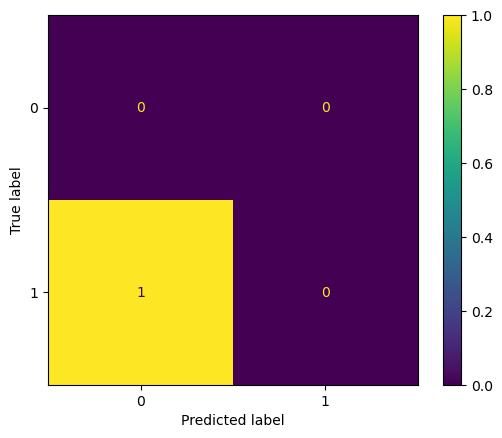

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [50]:
import pandas as pd

importance = model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": x.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

imp_df

,Feature,Importance
4,execrise_minutes,0.230037
1,screen_time,0.218315
0,sleep_hours,0.200733
3,mood,0.182418
2,work_hours,0.168498
